## Learning objectives

By the end of this activity, students should be able to

1. Train neural networks

2. Change model architecture and choose an appropriate loss function, metric, optimizer.

3. Regularize neural networks

## Mode

Please run the Python chunks one by one, look at the output and make sure that you understand how it is produced. There will be questions that either require a short answer - then you type your answer right in this document - or writing Python codes - then you write the Python codes here. In either case, you can discuss your work with your teammmates and with Fedor.

# Data

We will work with companies bankruptcy data (it comes from Poland)

<!-- Source: https://www.kaggle.com/c/companies-bankruptcy-forecast/data -->

Source with explanation of the features: https://archive.ics.uci.edu/ml/datasets/Polish+companies+bankruptcy+data

The objective is to construct a machine learning model that will predict if a company bankrupts.

In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import numpy as np
import pandas as pd
import plotly.express as px

from numpy.random import seed
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout
from tensorflow.keras import regularizers



# Data

Now we will load the data.

In [35]:
!wget "https://archive.ics.uci.edu/ml/machine-learning-databases/00365/data.zip"
!unzip -q data.zip
!ls

--2025-02-04 06:32:32--  https://archive.ics.uci.edu/ml/machine-learning-databases/00365/data.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘data.zip.2’

data.zip.2              [ <=>                ]   8.42M  --.-KB/s    in 0.1s    

2025-02-04 06:32:32 (64.0 MB/s) - ‘data.zip.2’ saved [8834471]

replace 1year.arff? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace 2year.arff? [y]es, [n]o, [A]ll, [N]one, [r]ename: N
1year.arff  3year.arff	5year.arff  data.zip.1	sample_data
2year.arff  4year.arff	data.zip    data.zip.2


There are several data files here. We will merge them into one dataframe.

In [36]:
from scipy.io import arff
import glob

filenames = glob.glob("*.arff")
print("We will read data from the following files:", filenames)

dfs = [] # This is going to be a list of dataframes, each dataframe containing
# one data file

for filename in filenames:
    data = arff.loadarff(filename)
    df = pd.DataFrame(data[0])
    dfs.append(df)
    print("\nFile =", filename)
    print("dim(df) =", df.shape)

# Concatenate all data into one DataFrame
all_data = pd.concat(dfs, ignore_index=True)
print("dim(all data) =", all_data.shape)
all_data.head()

We will read data from the following files: ['5year.arff', '2year.arff', '3year.arff', '4year.arff', '1year.arff']

File = 5year.arff
dim(df) = (5910, 65)

File = 2year.arff
dim(df) = (10173, 65)

File = 3year.arff
dim(df) = (10503, 65)

File = 4year.arff
dim(df) = (9792, 65)

File = 1year.arff
dim(df) = (7027, 65)
dim(all data) = (43405, 65)


,Attr1,Attr2,Attr3,Attr4,Attr5,Attr6,Attr7,Attr8,Attr9,Attr10,...,Attr56,Attr57,Attr58,Attr59,Attr60,Attr61,Attr62,Attr63,Attr64,class
0,0.088238,0.55472,0.01134,1.0205,-66.5200,0.342040,0.109490,0.57752,1.0881,0.32036,...,0.080955,0.275430,0.91905,0.002024,7.2711,4.7343,142.760,2.5568,3.2597,b'0'
1,-0.006202,0.48465,0.23298,1.5998,6.1825,0.000000,-0.006202,1.06340,1.2757,0.51535,...,-0.028591,-0.012035,1.00470,0.152220,6.0911,3.2749,111.140,3.2841,3.3700,b'0'
2,0.130240,0.22142,0.57751,3.6082,120.0400,0.187640,0.162120,3.05900,1.1415,0.67731,...,0.123960,0.192290,0.87604,0.000000,8.7934,2.9870,71.531,5.1027,5.6188,b'0'
3,-0.089951,0.88700,0.26927,1.5222,-55.9920,-0.073957,-0.089951,0.12740,1.2754,0.11300,...,0.418840,-0.796020,0.59074,2.878700,7.6524,3.3302,147.560,2.4735,5.9299,b'0'
4,0.048179,0.55041,0.10765,1.2437,-22.9590,0.000000,0.059280,0.81682,1.5150,0.44959,...,0.240400,0.107160,0.77048,0.139380,10.1180,4.0950,106.430,3.4294,3.3622,b'0'


Now we will remove rows containing missing values

In [37]:
 all_data = all_data.dropna()

 print("dim(data)=", all_data.shape)
 print("Summary of the response variable:")
 all_data["class"].value_counts()

dim(data)= (19967, 65)
Summary of the response variable:


,count
class,
b'0',19535
b'1',432


In [38]:
all_data.shape

(19967, 65)

The dataset is very imbalanced. Before dealing with it, let's quickly look at a scatterplot:

In [39]:
px.scatter(all_data, x = 'Attr1', y = 'Attr2', opacity=0.5, color = 'class')

We see that there is one observation that is an extreme outlier. It is probably some error, so we will just remove it.

In [40]:
all_data = all_data.loc[all_data['Attr1'] < 20 , :]
px.scatter(all_data, x = 'Attr1', y = 'Attr2', opacity=0.5, color = 'class')

We see that points representing positive examples (companies that went bankrupt) form some kind of a blob in the middle of the dataset. Try to move the cursor around the plot - you will see that the majority of points in that blob are still negative examples, which means that it will be very hard to predict that a company goes bankrupt.

There are some strategies to deal with imbalanced datasets:

1. Oversampling - randomly duplicating examples in the minority class

2. Undersampling - randomly deleting examples in the majority class

3. Introducing weights in the loss function

4. Changing the probability threshold for class prediction

You are encouraged to do your own research on the issue. Since our primary learning objective today is training artificial neural networks, we will choose option 2 - undersampling. We will manually rebalance the data by deleting the majority of the negative class.

We will do it by creating a random vector with the same number of entries as the number of observations in the dataset. It will have True entries at positions corresponding to all positive examples from the data and at random posititions for negative examples. Let's say, we will keep around 600 negative examples in our dataset.

In [41]:

seed(42) # this is for reproducibility

positive_class = all_data["class"].unique()[1]
print("Positive class is", positive_class)

p = 600 / np.sum(all_data["class"] != positive_class)
ind_for_keeping = (np.random.rand(all_data.shape[0]) < p)
ind_for_keeping[all_data["class"] == positive_class] = True

balanced_data = all_data.loc[ind_for_keeping, :]
print(balanced_data["class"].value_counts())
px.scatter(balanced_data, x = 'Attr1', y = 'Attr2', opacity=0.5, color = 'class')

Positive class is b'1'
class
b'0'    586
b'1'    432
Name: count, dtype: int64


Now we will create training and test datasets. Note that we need to separate $X$ from $Y$.

In [42]:
all_x = balanced_data.filter(like = "Attr", axis = 1) # this extracts columns whose name contains "Attr"
all_y = 0. + (balanced_data['class'] == positive_class) # converting positive class to 1 and negative to 0

x_train, x_test, y_train, y_test = train_test_split(all_x, all_y, test_size=0.5, random_state = 8128)
print("X dimensions =", all_x.shape)
print("Y dimensions =", all_y.shape)
print("Train X dimensions =", x_train.shape)
print("Train Y dimensions =", y_train.shape)
print("Test X dimensions =", x_test.shape)
print("Test Y dimensions =", y_test.shape)

X dimensions = (1018, 64)
Y dimensions = (1018,)
Train X dimensions = (509, 64)
Train Y dimensions = (509,)
Test X dimensions = (509, 64)
Test Y dimensions = (509,)


# Exercise 1

Suppose that our base model predicts that a company never bankrupts. What is the test accuracy of such a base model?

In [43]:
test_acc = np.sum(y_test==0)/y_test.shape[0]
print('Test Accuracy: {}'.format(test_acc))

Test Accuracy: 0.5618860510805501



# Model

Here is how we define our model. Let's say we will create an artificial neural network with 2 hidden layers of dimensions, say, 10 and 5, respectively. There will be one output layer.

Note that activation functions in the hidden layers are `relu` - this is the default choice and you probably shouldn't change it unless you have some recommendations in literature for your particular problem. The activation in the output layer should be `sigmoid` since we are doing binary classification.

### Exercise 2

Figure out how many parameters such a model will have. Just uncomment `print(model.summary())` the next cell to see the answer

__END OF EXERCISE 2__

In [44]:
# This is for repdoducibility:
seed(42)
tf.random.set_seed(496)

# Here is a model with 2 hidden layers of dimensions 10 and 5 respectively
model = Sequential()
model.add(Dense(10, input_dim=64, activation='relu')) # 65*10
model.add(Dense(5, activation='relu')) # 11*5
model.add(Dense(1, activation='sigmoid')) #6*1

### Uncommend to see the answer to the exericse:
print(model.summary())

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_58 (Dense)                     │ (None, 10)                  │             650 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_59 (Dense)                     │ (None, 5)                   │              55 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_60 (Dense)                     │ (None, 1)                   │               6 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 711 (2.78 KB)

 Trainable params: 711 (2.78 KB)

 Non-trainable params: 0 (0.00 B)

None


Note that `model` is a variable of a special class `Sequential`. One of its methods is `add` - we use it to construct the model layer by layer. All deep learning models that you will see in this course are constructed layer by layer, but you should know that there exist other, more complicated, model architectures.

Now the model has been created and its parameters (weights and biases) have been randomly initialized. They can be extracted from the model if needed:

In [45]:
print("Number of elements in the list of weights and biases:", len(model.weights))
print("\n Hidden layer 1:")
print("dim(W) =", model.weights[0].shape)
print("dim(b) =", model.weights[1].shape)
print("Sample of weights in hidden layer 1:")
print(model.weights[0][:5, :5])
print("Sample of biases in hidden layer 1:")
print(model.weights[1][:5])

print("\n Hidden layer 2:")
print("dim(W) =", model.weights[2].shape)
print("dim(b) =", model.weights[3].shape)

print("\n Output layer 3:")
print("dim(W) =", model.weights[4].shape)
print("dim(b) =", model.weights[5].shape)


Number of elements in the list of weights and biases: 6

 Hidden layer 1:
dim(W) = (64, 10)
dim(b) = (10,)
Sample of weights in hidden layer 1:
tf.Tensor(
[[ 0.1825738  -0.27895117  0.22821793  0.22234496  0.1977601 ]
 [ 0.11634591 -0.08986795  0.02899447 -0.08556168 -0.1665805 ]
 [-0.2720317   0.20367047 -0.15221578 -0.21159115  0.06919187]
 [-0.15058134 -0.03171268 -0.19897112 -0.28335303  0.25033268]
 [ 0.28111836 -0.11057262 -0.24305095 -0.00932294  0.14538273]], shape=(5, 5), dtype=float32)
Sample of biases in hidden layer 1:
tf.Tensor([0. 0. 0. 0. 0.], shape=(5,), dtype=float32)

 Hidden layer 2:
dim(W) = (10, 5)
dim(b) = (5,)

 Output layer 3:
dim(W) = (5, 1)
dim(b) = (1,)


Now we can construct predictions (even though they are meaningless at the moment). Let's do it to understand how deep learning models work.

In [46]:
x = np.array(x_train.iloc[3, :]).reshape(1, 64)
print("Sample of input =", x[: , :5])
print("Final prediction should be:", model.predict(x))
print("Layer 1:")
z = np.array(np.dot(x, model.weights[0]) + model.weights[1])
print("z = Wx+b =", z)
a = np.maximum(z, 0)
print("a = relu(z) =", a)

print("Layer 2:")
z = np.array(np.dot(a, model.weights[2]) + model.weights[3])
print("z = Wa+b =", z)
a = np.maximum(z, 0)
print("a = relu(z) =", a)

print("Layer 3:")
z = np.array(np.dot(a, model.weights[4]) + model.weights[5])
print("z = Wa+b =", z)
a = 1. / (1. + np.exp(-z))
print("a = sigmoid(z) =", a)

Sample of input = [[ 2.3532e-02  7.5825e-01 -1.1758e-01  8.3109e-01 -6.8569e+01]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
Final prediction should be: [[1.]]
Layer 1:
z = Wx+b = [[ -120.99554826   196.72370364   193.68007717   869.39999649
  -1219.03440799   -46.88980774  -287.39968361   137.39220649
    -38.58760691   644.66371505]]
a = relu(z) = [[  0.         196.72370364 193.68007717 869.39999649   0.
    0.           0.         137.39220649   0.         644.66371505]]
Layer 2:
z = Wa+b = [[-323.14368482  326.01873855  338.09316729 -310.48175454 -329.66664842]]
a = relu(z) = [[  0.         326.01873855 338.09316729   0.           0.        ]]
Layer 3:
z = Wa+b = [[176.80279772]]
a = sigmoid(z) = [[1.]]


Model parameter values will be updated in the training process via gradient descent. To start gradient descent, we need to set some important options and controls.

Note that the loss function is `binary_crossentropy`. We chose it because the problem is binary classification. Model training is done by gradient descent that tries to minimize the loss function.

On the other hand, the metric is `accuracy` because ultimately we are interested in the accuracy of our model, i.e., fraction of test examples that it correctly predicts.

Further, the optimizer is `adam`. The list of all optimizers available in `keras` can be found here:

* https://www.tensorflow.org/api_docs/python/tf/keras/optimizers

Note that the choice of an optimizer and its hyperparameters (each optimizer has its own hyperparameters) may be important. Now we will just use `adam`.

If you are interested in theory behind these optimizers, here is a reference for you:

* https://ruder.io/optimizing-gradient-descent/

This material won't appear on tests

In [47]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

So far we haven't started training yet. To do it, we need to choose the number of epochs. An epoch is one pass through the entire training set. Usually, this is done in mini-batches, i.e., every time we update our current parameter values by
$$
\Theta_{n+1} = \Theta_n- \alpha\nabla_J(\Theta_n),
$$
where $J$ is the loss function, we compute the gradient on some small subset of the training set. Training by mini-batches speeds up the process if the training set is very large (which is not the case now, but often is).

Both the number of epochs and the batch size are hyperparameters of the training process.

In [48]:
num_epochs = 20
print("Training for", num_epochs, "epochs")
history = model.fit(x_train, y_train, epochs=num_epochs, batch_size=128)

Training for 20 epochs
Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 144ms/step - accuracy: 0.4002 - loss: 282.2616
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3999 - loss: 257.7342 
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4022 - loss: 235.4454 
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4140 - loss: 214.1684 
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4229 - loss: 193.8542 
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4226 - loss: 173.5209 
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4218 - loss: 152.5035 
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4328 - loss: 131.7083
Epoch 9/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4380 - loss: 111.6241
Epoch 10/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4570 - loss: 93.0872  
Epoch 11/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4578 - loss: 78.1858 
Epoch 12/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 1

Notice how accuracy goes up first and then goes down, even though the loss goes down all the way.

To see it better, we can now plot the accuracy vs the epoch. First, we will extract this and save it into a dataframe.

In [49]:
train_history = pd.DataFrame(history.history)
train_history["epoch"] = np.arange(num_epochs) + 1
train_history

,accuracy,loss,epoch
0,0.402750,295.625549,1
1,0.396857,270.158752,2
2,0.402750,246.848602,3
3,0.414538,224.709534,4
4,0.418468,203.701981,5
5,0.418468,182.668594,6
6,0.416503,160.983612,7
7,0.420432,139.694473,8
8,0.420432,119.433357,9
9,0.440079,100.935333,10


In [50]:
fig = px.line(train_history, x = 'epoch', y = 'accuracy')
fig.show()


Now let us look at our model's test performance

In [51]:
# evaluate the keras model
_, test_acc = model.evaluate(x_test, y_test)
print('Test Accuracy: %.2f' % (test_acc * 100))

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3636 - loss: 25.3970
Test Accuracy: 39.49


The raw accuracy doesn't tell much. Let us look at the entire confusion matrix.

First, we need to compute predictions of our model on the test data.

Observe that raw predictions are probabilities:

In [52]:
print("Sample of raw predictions:")
print(model.predict(x_test)[:10])

Sample of raw predictions:
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
[[0.4824793 ]
 [0.4824793 ]
 [1.        ]
 [1.        ]
 [0.33156416]
 [0.4824793 ]
 [0.74551606]
 [1.        ]
 [0.7732394 ]
 [0.8131034 ]]


Naturally, we will just predict that a company bankrupts if the estimated probability of bankrupcy is above 0.5

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
We predict that 257.0 companies go bankrupt
Here is the confusion matrix:
[[115 171]
 [137  86]]


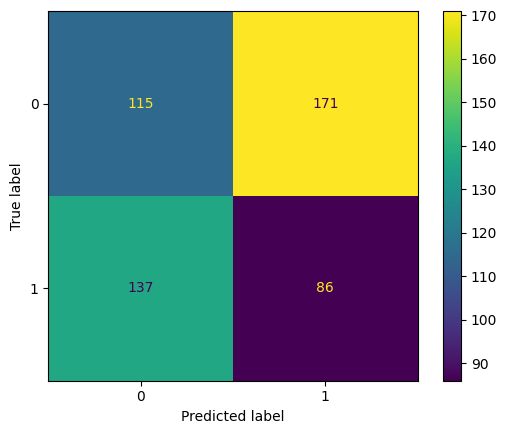

In [53]:
y_pred = 0. + (model.predict(x_test) > 0.5)

print("We predict that", np.sum(y_pred), "companies go bankrupt")
print("Here is the confusion matrix:")
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

Our model does not perform very well 😖

What if we try to make it more complex?

### Exercise 3

Construct a new model with 3 hidden layers of dimensions 300 and 200, and 100 respectively.

We will train it for 100 epochs and we will also track its test accuracy on the go.

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_61 (Dense)                     │ (None, 300)                 │          19,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_62 (Dense)                     │ (None, 200)                 │          60,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_63 (Dense)                     │ (None, 100)                 │          20,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_64 (Dense)                     │ (None, 1)                   │             101 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 99,901 (390.24 KB)

 Trainable params: 99,901 (390.24 KB)

 Non-trainable params: 0 (0.00 B)

None
Training model 2 for 100 epochs


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6677 - loss: 18.8604
Test Accuracy: 65.03
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
We predict that 153.0 companies go bankrupt
Here is the confusion matrix:
[[232  54]
 [124  99]]
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


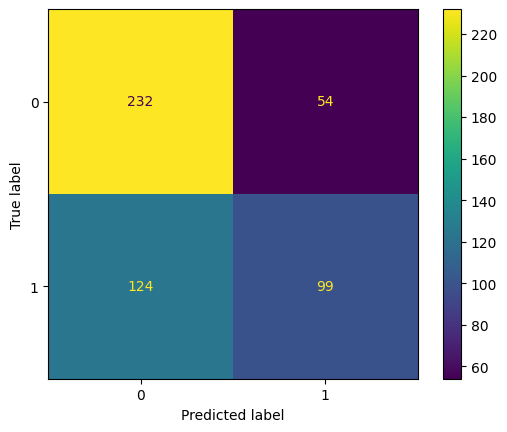

In [54]:
### For reproducibility:

seed(42)
tf.random.set_seed(496)

###### Make changes here:
mod2 = Sequential()
mod2.add(Dense(300, input_dim=64, activation='relu'))
mod2.add(Dense(200, activation='relu'))
mod2.add(Dense(100, activation='relu'))
mod2.add(Dense(1, activation='sigmoid'))
print(mod2.summary())

############################################

mod2.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

num_epochs = 100
print("Training model 2 for", num_epochs, "epochs")
# We will set "verbose = 0" to prevent long output
# And batch size = 512 so that the entire training set (it has 512 observations)
# will be use for updating the gradient
history = mod2.fit(x_train, y_train, validation_data=(x_test, y_test), \
                   verbose = 0, epochs=num_epochs, batch_size=512)

def plot_train_history(hist):
    train_history = pd.DataFrame(hist.history)
    train_history["epoch"] = np.arange(num_epochs) + 1
    fig = px.line(train_history, x = 'epoch', y = ['accuracy', 'val_accuracy'])
    return fig

def bankrupt_model_eval(mod):
    _, test_acc = mod.evaluate(x_test, y_test)
    print('Test Accuracy: %.2f' % (test_acc * 100))
    y_pred = 0. + (mod.predict(x_test) > 0.5)
    print("We predict that", np.sum(y_pred), "companies go bankrupt")
    print("Here is the confusion matrix:")
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    print(cm)
    y_pred = 0. + (model.predict(x_test) > 0.5)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    return(disp)

plot_train_history(history).show()
bankrupt_model_eval(mod2)

# Regularization

We will introduce two methods of regularization. One of them is the familiar $l_1$-regularization. Doing $l_1$-regularization for the first hidden layer means that the loss function gets the extra term
$$
+\lambda\sum_{k,l}|w^{1}_{k,l}|,
$$
where the sum is taken over all weights in the first hidden layer.
Note that we could apply $l_1$- and $l_2$-regularization for all hidden layers, which means a lot of hyperparameters. You can read more about it here:

* https://keras.io/api/layers/regularizers/

For the purpose of our task (learning how to train neural networks), we will just regularize the first hidden layer.

The second type or regularization is dropout regularization. The idea here is that deep learning models may overfit when they become dependent on the output of a particular neuron. To avoid this effect, we introduce a _dropout layer_ that will just change a  fraction of entries in the previous layer's output to 0. The dropout layer is only used in training to prevent overfitting. Later, when we use the model to construct predictions on new data, the dropout layer is not used any more.

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_65 (Dense)                     │ (None, 300)                 │          19,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_66 (Dense)                     │ (None, 200)                 │          60,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_17 (Dropout)                 │ (None, 200)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_67 (Dense)                     │ (None, 1)                   │             201 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 79,901 (312.11 KB)

 Trainable params: 79,901 (312.11 KB)

 Non-trainable params: 0 (0.00 B)

None
Training model 3 for 100 epochs


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6627 - loss: 7.9496
Test Accuracy: 67.98
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
We predict that 220.0 companies go bankrupt
Here is the confusion matrix:
[[206  80]
 [ 83 140]]
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


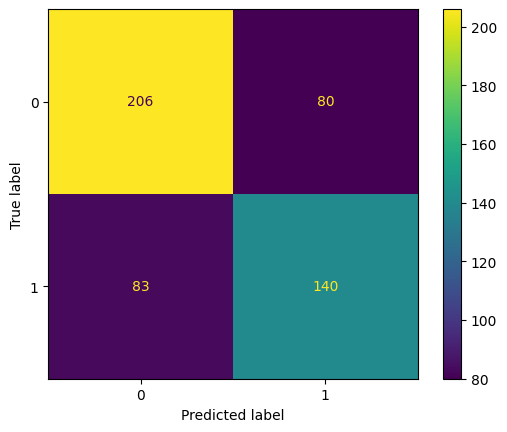

In [55]:
### For reproducibility: # l1 lambda = 0.01 and dropout = 0.2

seed(42)
tf.random.set_seed(496)

###### Make changes here:
mod3 = Sequential()
mod3.add(Dense(300, input_dim=64, activation='relu', kernel_regularizer=regularizers.l1(0.01)))
mod3.add(Dense(200, activation='relu'))
mod3.add(Dropout(0.5))
mod3.add(Dense(1, activation='sigmoid'))
print(mod3.summary())

############################################

mod3.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

num_epochs = 100
print("Training model 3 for", num_epochs, "epochs")
history = mod3.fit(x_train, y_train, validation_data=(x_test, y_test), \
                   verbose = 0, epochs=num_epochs, batch_size=512)


plot_train_history(history).show()
bankrupt_model_eval(mod3)

### Exercise 4

Play with two regularization constants and see how it affects the training process and the final accuracy. Will you be able to achieve a higher training accuracy?

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Training with L1 Lambda: 0.01, Dropout Rate: 0.1
Final Train Accuracy: 0.6896
Final Test Accuracy: 0.6974


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7045 - loss: 40.6226
Test Accuracy: 69.74
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
We predict that 245.0 companies go bankrupt
Here is the confusion matrix:
[[198  88]
 [ 66 157]]
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Training with L1 Lambda: 0.01, Dropout Rate: 0.2


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Final Train Accuracy: 0.6739
Final Test Accuracy: 0.6248


...

Final Train Accuracy: 0.6640
Final Test Accuracy: 0.6503


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6284 - loss: 120.0963
Test Accuracy: 65.03
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
We predict that 139.0 companies go bankrupt
Here is the confusion matrix:
[[239  47]
 [131  92]]
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Training with L1 Lambda: 1.0, Dropout Rate: 0.8


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Final Train Accuracy: 0.6149
Final Test Accuracy: 0.6346


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6270 - loss: 126.2430
Test Accuracy: 63.46
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
We predict that 93.0 companies go bankrupt
Here is the confusion matrix:
[[258  28]
 [158  65]]
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


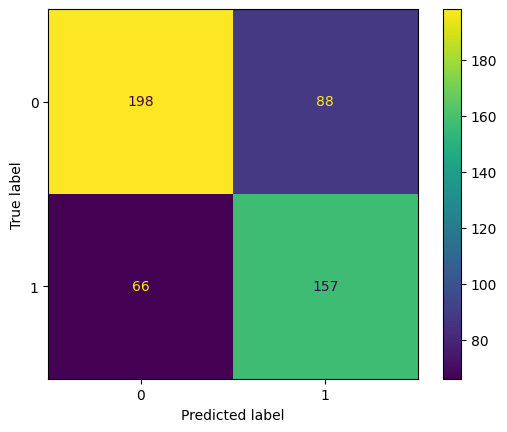

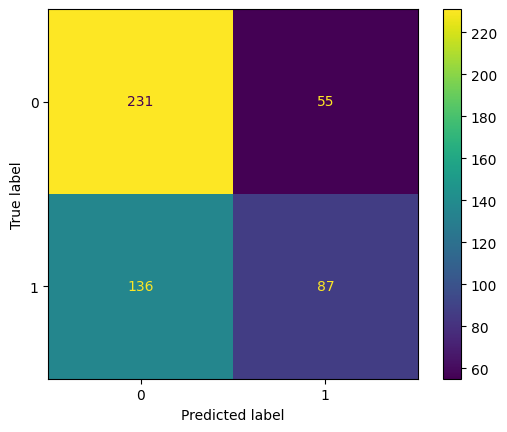

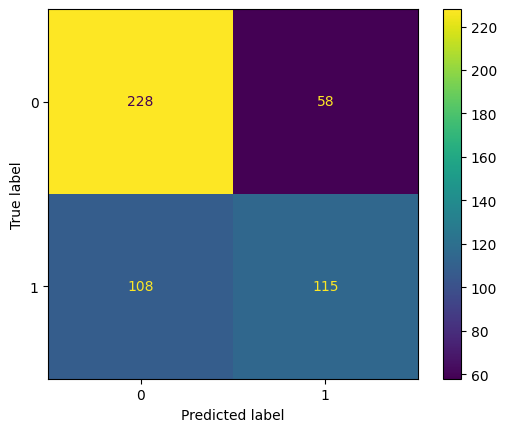

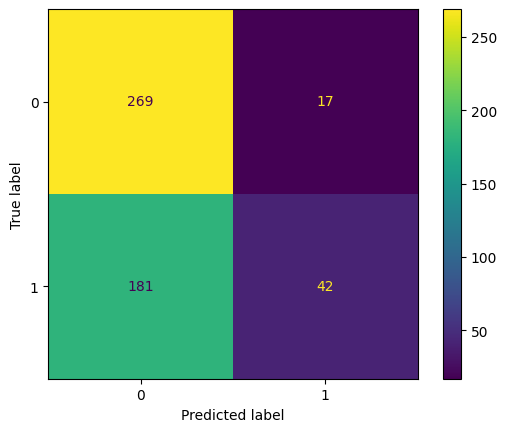

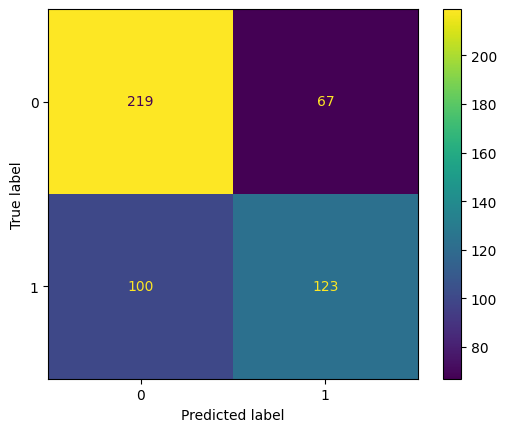

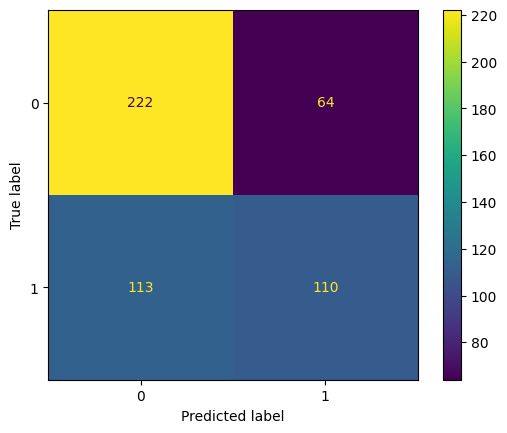

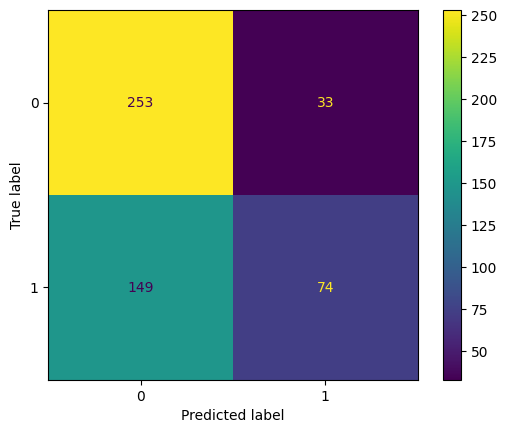

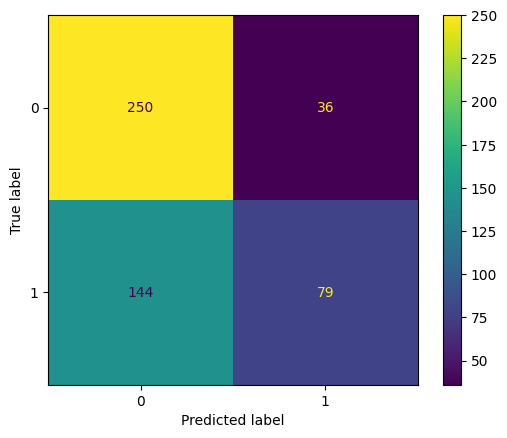

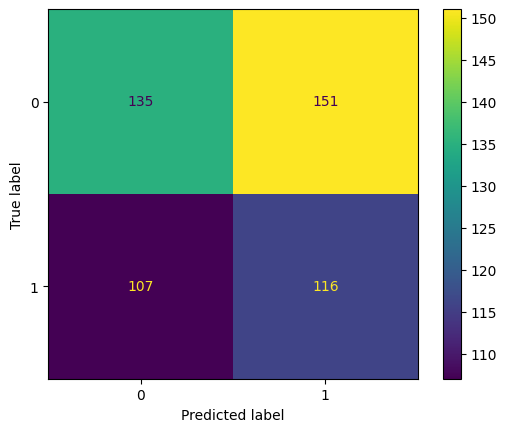

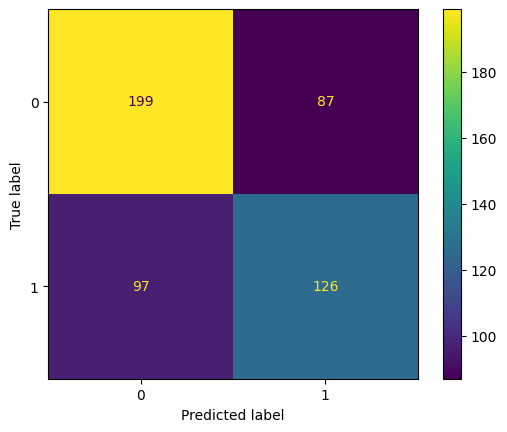

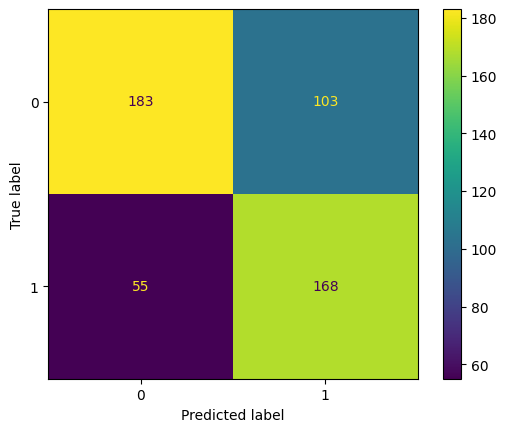

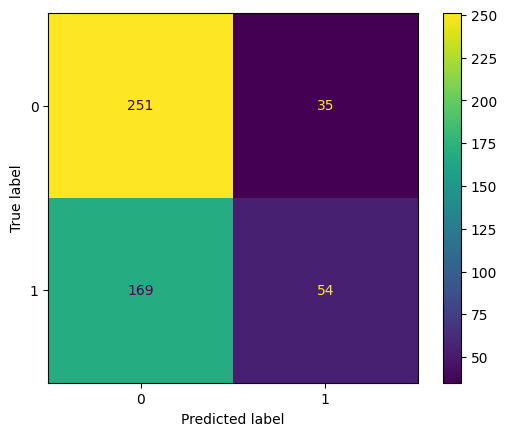

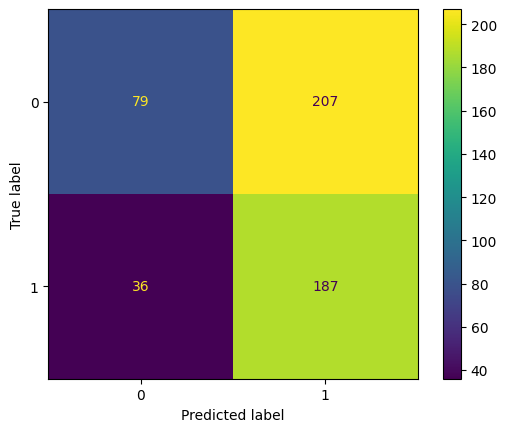

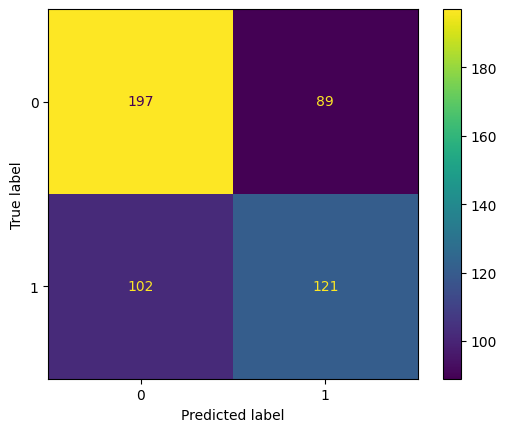

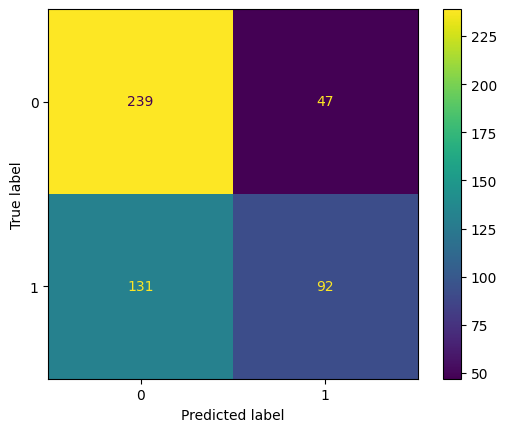

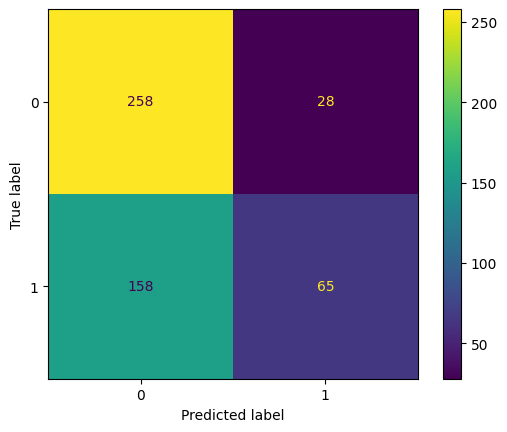

In [56]:
# For reproducibility
np.random.seed(42)
tf.random.set_seed(496)

def build_and_train_model(l1_lambda, dropout_rate, num_epochs=100, batch_size=512):
    mod3 = Sequential()
    mod3.add(Dense(300, input_dim=64, activation='relu', kernel_regularizer=regularizers.l1(l1_lambda)))
    mod3.add(Dense(200, activation='relu'))
    mod3.add(Dropout(dropout_rate))
    mod3.add(Dense(1, activation='sigmoid'))

    mod3.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

    print(f"Training with L1 Lambda: {l1_lambda}, Dropout Rate: {dropout_rate}")
    history = mod3.fit(x_train, y_train, validation_data=(x_test, y_test),
                       verbose=0, epochs=num_epochs, batch_size=batch_size)

    train_acc = history.history['accuracy'][-1]
    test_acc = history.history['val_accuracy'][-1]

    print(f"Final Train Accuracy: {train_acc:.4f}")
    print(f"Final Test Accuracy: {test_acc:.4f}")

    plot_train_history(history).show()
    bankrupt_model_eval(mod3)

    return mod3

# Example: Tune hyperparameters
l1_lambda_values = [0.01, 0.1,0.5,1.0]  # Example values for L1 regularization
dropout_values = [0.1,0.2, 0.5,0.8]  # Example values for Dropout

for l1 in l1_lambda_values:
    for dropout in dropout_values:
        build_and_train_model(l1_lambda=l1, dropout_rate=dropout)


# Questions for discussion

## Question 1

Here, we just removed observations containing NA values for some of the attributes. Is it a good strategy? What would you do in practice, i.e., if you worked in risk evaluation team in a bank and you needed an ML model to predict how likely companies that get credit from your bank are going to bankrupt?

## Question 2

Here, we removed the outlier. Again, what should be a good strategy of dealing with outliers in practice?

## Question 3

Suggest a strategy of finding a good combination of hyperparameter values in practice (what would you do if you needed to train such a model for risk evaluation in an actual bank?):

* Number of layers and layer dimensions

* Number of epochs and batch size

* Regularization constants

# Fedor's answers

Answers to exercises 1-3 are available here:

https://colab.research.google.com/drive/1gVdx1iL76O6QLplrJz5IHPTfLP5cHKgL?usp=sharing